# Hasil eksekusi Colab: 10_validasi_eksternal

Dijalankan di VM Colab GPU T4 (sesi `d920cd`). Sel di bawah adalah kode notebook asli beserta outputnya.


In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import (roc_auc_score, recall_score, precision_score,
                             f1_score, confusion_matrix, roc_curve)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
SEED = 42

CDC = "https://archive.ics.uci.edu/static/public/891/data.csv"
KAGGLE = ("https://raw.githubusercontent.com/ray-project/raydp/master/"
          "tutorials/dataset/healthcare-dataset-stroke-data.csv")

FITUR = ["sex", "umur_kel", "tekanan_darah_tinggi", "penyakit_jantung", "bmi", "perokok"]

# CDC mengelompokkan umur ke 13 kelompok; ini batas atas tiap kelompok (18-24, 25-29, ...)
BATAS_UMUR = [24, 29, 34, 39, 44, 49, 54, 59, 64, 69, 74, 79]

In [ ]:
def dari_cdc():
    d = pd.read_csv(CDC)
    return pd.DataFrame({
        "sex": d.Sex,
        "umur_kel": d.Age,
        "tekanan_darah_tinggi": d.HighBP,
        "penyakit_jantung": d.HeartDiseaseorAttack,
        "bmi": d.BMI,
        "perokok": d.Smoker,
        "stroke": d.Stroke,
    })


def dari_kaggle():
    d = pd.read_csv(KAGGLE)
    d = d[(d.age >= 18) & (d.gender != "Other") & (d.smoking_status != "Unknown")].copy()
    d["bmi"] = d.bmi.fillna(d.bmi.median())
    return pd.DataFrame({
        "sex": (d.gender == "Male").astype(int),
        "umur_kel": np.digitize(d.age, BATAS_UMUR) + 1,
        "tekanan_darah_tinggi": d.hypertension,
        "penyakit_jantung": d.heart_disease,
        "bmi": d.bmi,
        "perokok": d.smoking_status.isin(["formerly smoked", "smokes"]).astype(int),
        "stroke": d.stroke,
    })


cdc = dari_cdc()
kaggle = dari_kaggle()

ringkas = pd.DataFrame([
    {"Dataset": "CDC BRFSS 2015", "baris": len(cdc), "kasus stroke": int(cdc.stroke.sum()),
     "% stroke": round(cdc.stroke.mean() * 100, 2)},
    {"Dataset": "Kaggle (setelah diselaraskan)", "baris": len(kaggle),
     "kasus stroke": int(kaggle.stroke.sum()), "% stroke": round(kaggle.stroke.mean() * 100, 2)},
])
ringkas

,Dataset,baris,kasus stroke,% stroke
0,CDC BRFSS 2015,253680,10292,4.06
1,Kaggle (setelah diselaraskan),3391,202,5.96


In [ ]:
banding_pop = pd.DataFrame({
    "CDC BRFSS": cdc[FITUR].mean(),
    "Kaggle": kaggle[FITUR].mean(),
}).round(2)
banding_pop["selisih %"] = (100 * (banding_pop.Kaggle - banding_pop["CDC BRFSS"]).abs()
                            / banding_pop["CDC BRFSS"].abs()).round(1)
banding_pop

,CDC BRFSS,Kaggle,selisih %
sex,0.44,0.39,11.4
umur_kel,8.03,6.94,13.6
tekanan_darah_tinggi,0.43,0.13,69.8
penyakit_jantung,0.09,0.07,22.2
bmi,28.38,30.49,7.4
perokok,0.44,0.48,9.1


In [ ]:
MODEL = {
    "Logistic Regression": lambda: make_pipeline(
        StandardScaler(), LogisticRegression(max_iter=5000, random_state=SEED)),
    "Gradient Boosting": lambda: make_pipeline(
        StandardScaler(), GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.05, max_depth=2, random_state=SEED)),
}
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

hasil, terlatih, ambang = [], {}, {}

for nama, buat in MODEL.items():
    m = buat().fit(cdc[FITUR], cdc.stroke)
    terlatih[nama] = m

    # ambang dipilih dari sebaran probabilitas pada DATA LATIH saja
    p_latih = m.predict_proba(cdc[FITUR])[:, 1]
    t = np.quantile(p_latih, 1 - cdc.stroke.mean() * 4)
    ambang[nama] = t

    # AUC out-of-fold di dalam CDC: pembanding yang sah untuk angka data luar
    p_oof = cross_val_predict(buat(), cdc[FITUR], cdc.stroke, cv=cv,
                              method="predict_proba", n_jobs=-1)[:, 1]
    auc_oof = roc_auc_score(cdc.stroke, p_oof)

    for label, data in [("CDC (data latih sendiri)", cdc), ("Kaggle (DATA LUAR)", kaggle)]:
        p = m.predict_proba(data[FITUR])[:, 1]
        pred = (p >= t).astype(int)
        hasil.append({
            "Model": nama, "Diuji pada": label,
            "AUC": roc_auc_score(data.stroke, p),
            "AUC (OOF)": auc_oof if "CDC" in label else np.nan,
            "recall": recall_score(data.stroke, pred),
            "precision": precision_score(data.stroke, pred, zero_division=0),
            "f1": f1_score(data.stroke, pred),
            "ditandai %": 100 * pred.mean(),
        })

pd.DataFrame(hasil).round(3)

,Model,Diuji pada,AUC,AUC (OOF),recall,precision,f1,ditandai %
0,Logistic Regression,CDC (data latih sendiri),0.783,0.783,0.508,0.127,0.203,16.254
1,Logistic Regression,Kaggle (DATA LUAR),0.799,NaN,0.302,0.213,0.249,8.464
2,Gradient Boosting,CDC (data latih sendiri),0.786,0.785,0.526,0.128,0.206,16.705
3,Gradient Boosting,Kaggle (DATA LUAR),0.802,NaN,0.292,0.186,0.227,9.378


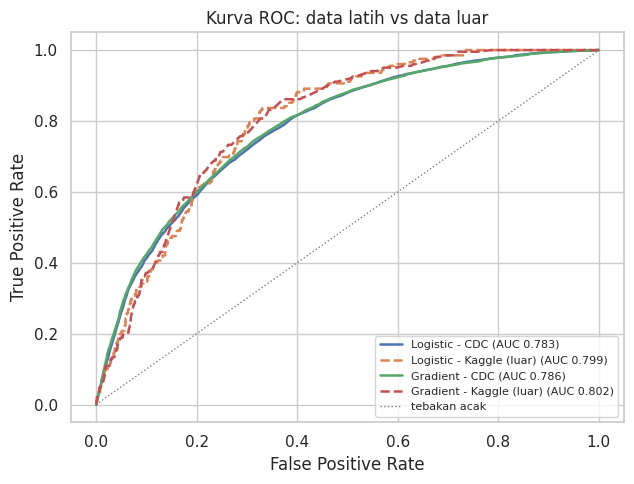

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for nama, m in terlatih.items():
    for label, data, gaya in [("CDC", cdc, "-"), ("Kaggle (luar)", kaggle, "--")]:
        p = m.predict_proba(data[FITUR])[:, 1]
        fpr, tpr, _ = roc_curve(data.stroke, p)
        ax.plot(fpr, tpr, gaya, lw=1.8,
                label=f"{nama.split()[0]} - {label} (AUC {roc_auc_score(data.stroke, p):.3f})")
ax.plot([0, 1], [0, 1], ":", color="grey", lw=1, label="tebakan acak")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Kurva ROC: data latih vs data luar")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

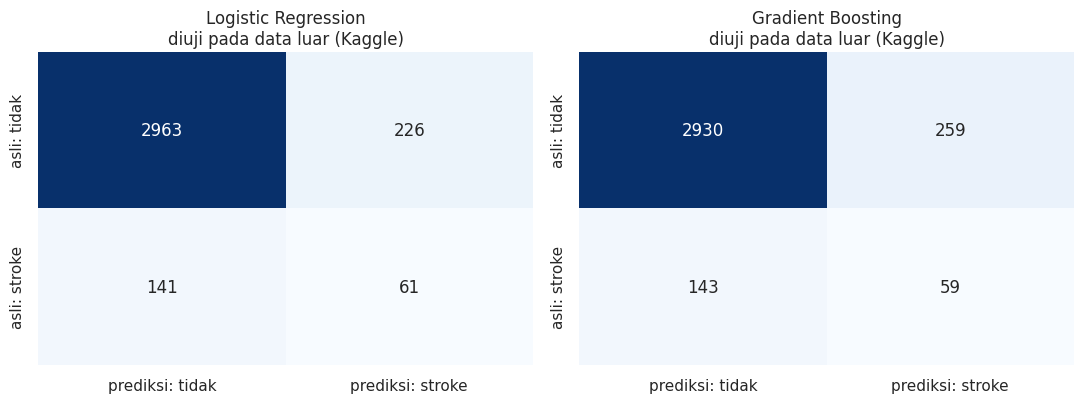

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
for i, (nama, m) in enumerate(terlatih.items()):
    pred = (m.predict_proba(kaggle[FITUR])[:, 1] >= ambang[nama]).astype(int)
    sns.heatmap(confusion_matrix(kaggle.stroke, pred), annot=True, fmt="d",
                cmap="Blues", cbar=False, ax=ax[i],
                xticklabels=["prediksi: tidak", "prediksi: stroke"],
                yticklabels=["asli: tidak", "asli: stroke"])
    ax[i].set_title(f"{nama}\ndiuji pada data luar (Kaggle)")
plt.tight_layout(); plt.show()

In [ ]:
hasil_balik = []
for nama, buat in MODEL.items():
    m = buat().fit(kaggle[FITUR], kaggle.stroke)
    p_latih = m.predict_proba(kaggle[FITUR])[:, 1]
    t = np.quantile(p_latih, 1 - kaggle.stroke.mean() * 4)

    for label, data in [("Kaggle (data latih sendiri)", kaggle), ("CDC (DATA LUAR)", cdc)]:
        p = m.predict_proba(data[FITUR])[:, 1]
        pred = (p >= t).astype(int)
        hasil_balik.append({
            "Model": nama, "Diuji pada": label,
            "AUC": roc_auc_score(data.stroke, p),
            "recall": recall_score(data.stroke, pred),
            "precision": precision_score(data.stroke, pred, zero_division=0),
            "ditandai %": 100 * pred.mean(),
        })

pd.DataFrame(hasil_balik).round(3)

,Model,Diuji pada,AUC,recall,precision,ditandai %
0,Logistic Regression,Kaggle (data latih sendiri),0.814,0.673,0.168,23.828
1,Logistic Regression,CDC (DATA LUAR),0.742,0.696,0.080,35.074
2,Gradient Boosting,Kaggle (data latih sendiri),0.837,0.703,0.176,23.857
3,Gradient Boosting,CDC (DATA LUAR),0.745,0.742,0.079,38.169


In [ ]:
# Baris yang sama persis dengan subset selaras, tetapi memakai SELURUH fitur Kaggle
k = pd.read_csv(KAGGLE).drop(columns=["id"])
k = k[(k.age >= 18) & (k.gender != "Other") & (k.smoking_status != "Unknown")].copy()
k["bmi"] = k.bmi.fillna(k.bmi.median())
X_lengkap = pd.get_dummies(k.drop(columns=["stroke"]), drop_first=True)
y_lengkap = k.stroke

assert len(y_lengkap) == len(kaggle), "baris harus sama persis dengan subset selaras"

LR = lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=SEED))

def auc_cv(Xd, yd):
    p = cross_val_predict(LR(), Xd, yd, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    return roc_auc_score(yd, p)

auc_lengkap = auc_cv(X_lengkap, y_lengkap)          # semua fitur, subset selaras
auc_enam    = auc_cv(kaggle[FITUR], kaggle.stroke)  # 6 fitur,    subset selaras
auc_eksternal = [h["AUC"] for h in hasil
                 if h["Model"] == "Logistic Regression" and "LUAR" in h["Diuji pada"]][0]

print(f"Subset selaras: {len(y_lengkap)} baris, {int(y_lengkap.sum())} kasus stroke")
print(f"  {X_lengkap.shape[1]} fitur, latih & uji di subset (CV)   : AUC {auc_lengkap:.3f}")
print(f"   6 fitur, latih & uji di subset (CV)    : AUC {auc_enam:.3f}")
print(f"   6 fitur, latih di CDC lalu uji di sini : AUC {auc_eksternal:.3f}")
print()
print(f"Harga kehilangan fitur     : {auc_lengkap - auc_enam:+.3f}")
print(f"Harga perpindahan populasi : {auc_enam - auc_eksternal:+.3f}")
print()
print("Sebagai pembanding, dari notebook 07 dan 11 (baris berbeda, jangan diselisihkan):")
print("  15 fitur, SEMUA umur          : AUC ~0,841")
print("  15 fitur, dewasa saja (>=18)  : AUC ~0,815")

Subset selaras: 3391 baris, 202 kasus stroke
  13 fitur, latih & uji di subset (CV)   : AUC 0.807
   6 fitur, latih & uji di subset (CV)    : AUC 0.810
   6 fitur, latih di CDC lalu uji di sini : AUC 0.799

Harga kehilangan fitur     : -0.003
Harga perpindahan populasi : +0.011

Sebagai pembanding, dari notebook 07 dan 11 (baris berbeda, jangan diselisihkan):
  15 fitur, SEMUA umur          : AUC ~0,841
  15 fitur, dewasa saja (>=18)  : AUC ~0,815
